In [6]:
import numpy as np
#import numpy.random as npr
import numpy.linalg as nla
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
import matplotlib.colors as mcol
#from scipy.optimize import curve_fit
import lmfit as lmft
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
import scipy.stats as sts
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn import linear_model
from sklearn.neighbors import KernelDensity

plt.style.use('./presentation.mplstyle')


In [7]:
sources = pd.read_csv('v1saga_dwarfs.csv')
print(sources.shape)

smorph = pd.read_csv('saga_morph.csv')
print(smorph.shape)

(6337, 26)
(6211, 78)


In [8]:
rd2deg = (180*3600)/np.pi

#mst = sources['logM'].iloc[morph_all[:,0,0]]
#zspec = sources['zspec'].iloc[morph_all[:,0,0]]
#res = 1e6*(0.262*cosmo.comoving_distance(zspec).value)/rd2deg

npr = {'gini':[[0.4,0.6],r'$Gini$',r'${\it G}$'],'m20':[[-2,-1],r'$M_{20}$',r'$M_{20}$'],
       'c':[[2,3.5],r'$Concentration$',r'${\it C}$'],'a':[[-0.3,0.3],r'$Asymmetry$',r'${\it A}$'],'s':[[-0.1,0.1],r'$Smoothness$',r'${\it S}$'],
       'rpetro':[[8,38],r'$Petrosian\ R$',r'$R_p$'],'n':[[0.0,4.0],r'$Sersic\ n$',r'${\it n}$'],'rhalf':[[0,20],r'$Sersic\ R$',r'$R_{0.5}$']}

def merger_line(M20): return -0.14*M20 + 0.33
def hubble_line(M20): return  0.14*M20 + 0.80
def SGM(G,M20): return 0.139*M20 + 0.99*G - 0.327
def BGM(G,M20): return -0.693*M20 + 4.95*G - 3.96

In [9]:
bands = {'g':[mcm.Blues,'tab:blue'],'r':[mcm.Greens,'tab:green'],'i':[mcm.Oranges,'tab:orange'],'z':[mcm.Reds,'tab:red']}

labels = [r'${\it g}$', r'${\it r}$', r'${\it i}$', r'${\it z}$']
positions = [0, 1, 2, 3]

(3698, 78)
(3947, 78)
(2357, 78)
(2415, 78)


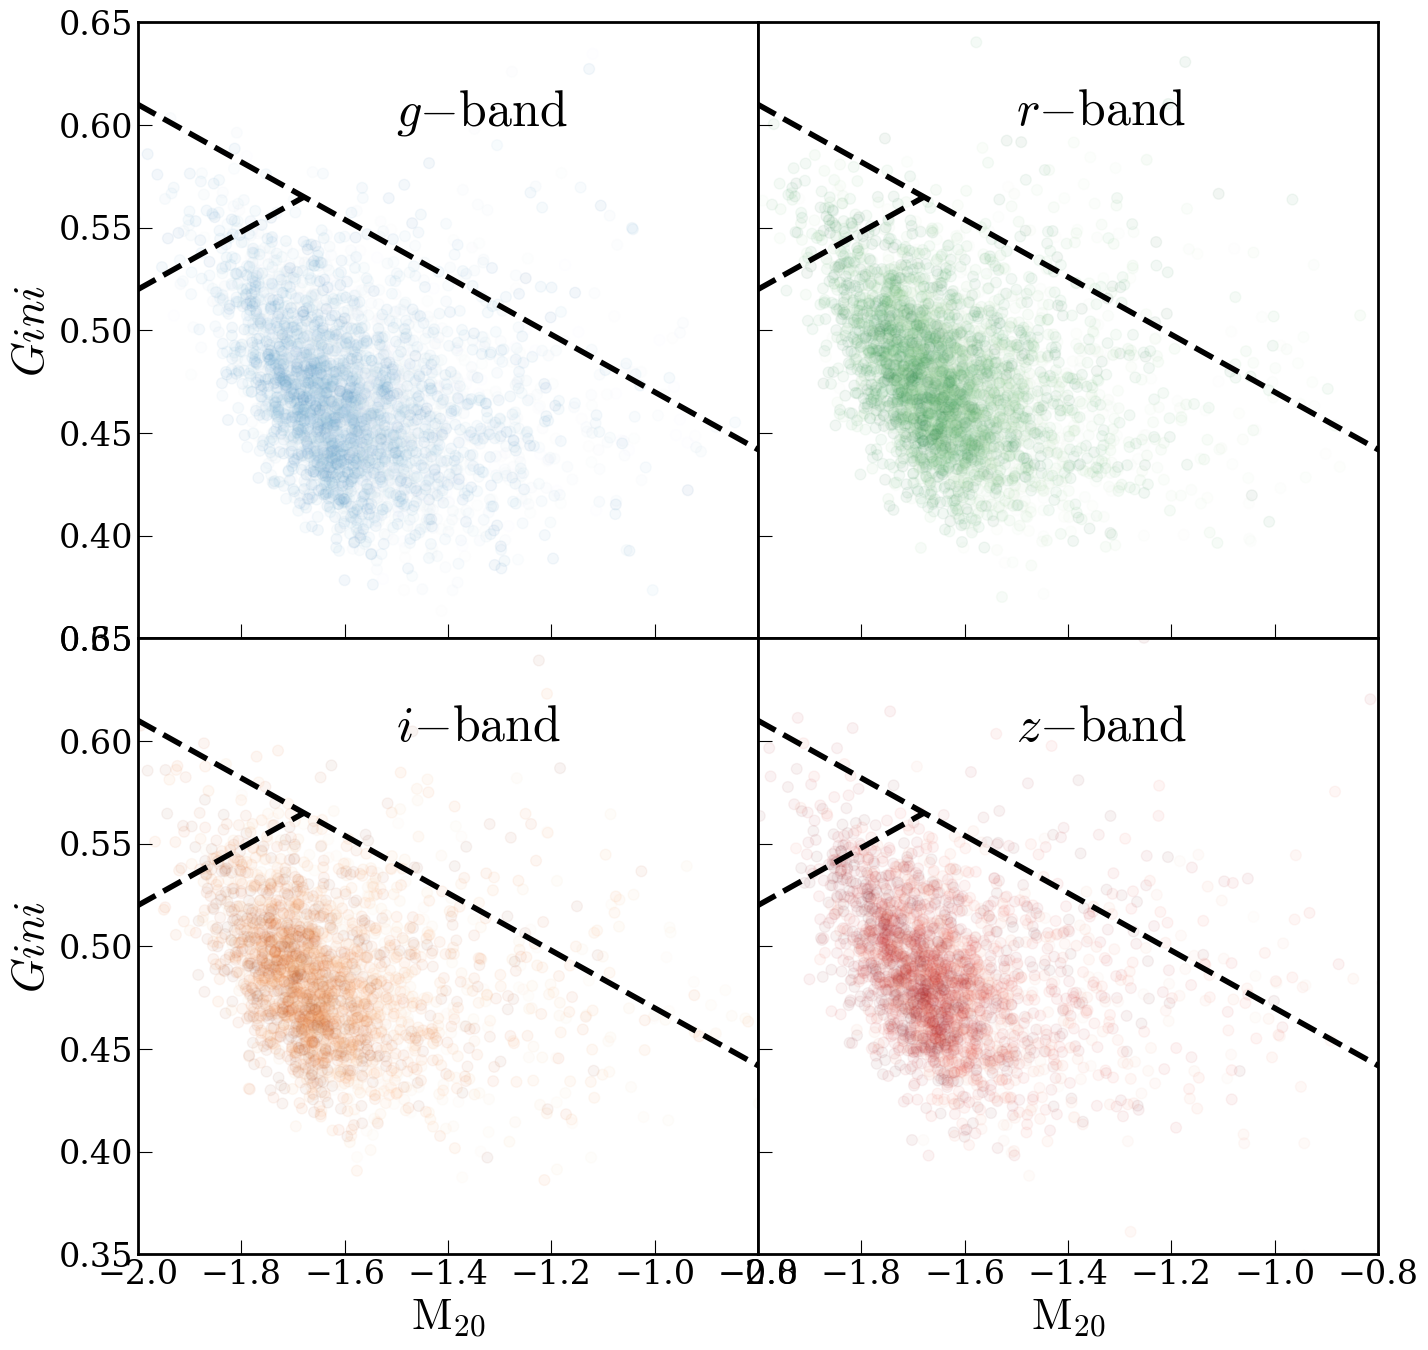

In [122]:
fig,axl=plt.subplots(2,2,figsize=(16,16),sharex=True,sharey=True)


hdx = [-2.0,-0.8,0.35,0.65]
M20_arr = np.linspace(-2.2,-0.4,21)
M20_arrhalf = np.linspace(-2.2,-1.68,11)

nbins = 10
hss_arr,resi_arr = np.zeros((4,nbins,nbins)),np.zeros((4,nbins,nbins))

for i,key in enumerate(bands):

    selc = smorph[(smorph['snr_pix_'+key]>2.5)&(smorph['flag_'+key]<=1)&(smorph['r20_psf_'+key]>0.5)]
    mag = sources['m_'+key+'0'].iloc[selc['ind1']]

    print(selc.shape)

    axl[i//2,i%2].plot(M20_arr,merger_line(M20_arr),lw=4,ls='--',color='black')
    axl[i//2,i%2].plot(M20_arrhalf,hubble_line(M20_arrhalf),lw=4,ls='--',color='black')

    #hss_arr[i],p0,p1,resi_arr[i] = hist_arr(selc['m20_'+key],selc['gini_'+key], hdx,nbins)
    
    im = axl[i//2,i%2].scatter(selc['m20_'+key],selc['gini_'+key],c=mag,s=60,cmap=bands[key][0].reversed(),vmin=18.1,vmax=20.9,alpha=0.05)

    axl[i//2,i%2].set_rasterized(True)
    axl[i//2,i%2].text(-1.5,0.6,labels[i]+r'$-band$',fontsize=36)
    axl[i//2,i%2].set_ylim((0.35,0.65))
    axl[i//2,i%2].set_xlim((-2.0,-0.8))

for j in range(2):
    axl[j,0].set_ylabel( r'${\it Gini}$',fontsize=32)
    axl[1,j].set_xlabel(r'$M_{20}$',fontsize=32)

plt.subplots_adjust(wspace=0.0,hspace=0.0)


In [117]:
'''
def gaussian_2d(xy, amplitude, x0, y0, sx, sy, offset):
    x, y = xy
    x_part,y_part = np.square((x - x0) / sx),np.square((y - y0) / sy)
    return offset + amplitude * np.exp(-0.5 * (x_part + y_part))
'''

def gaussian_2d(xy, mu_x, mu_y, sigma_x, sigma_y, rho, norm):
    x, y = xy
    norm_const = norm / (2 * np.pi * sigma_x * sigma_y * np.sqrt(1 - rho**2))
    
    # Standardized coordinates
    x_std = (x - mu_x) / sigma_x
    y_std = (y - mu_y) / sigma_y
    
    # Exponent term
    exponent = -1.0 * (np.square(x_std) - 2*rho*x_std*y_std + np.square(y_std))/(2*(1 - rho**2)) 
    
    return norm_const * np.exp(exponent)

initial_bound = [(-1,1),(-1,1),(1e-3,1),(1e-3,1),(-0.999,0.999),(0,1)]    

def hess_arr(x_val,y_val,hdex,nbins):
    x_val = (x_val - hdex[0])/(hdex[1]-hdex[0])
    y_val = (y_val - hdex[2])/(hdex[3]-hdex[2])
    dz=1.0/nbins
    
    xx,yy=np.meshgrid(np.arange(dz,1+dz,dz),np.arange(dz,1+2*dz,dz))
    xy_sample = np.vstack([yy[:-1].ravel(), xx[:-1].ravel()]).T
    xy_train  = np.vstack([y_val,x_val]).T

    kde_skl = KernelDensity(kernel='gaussian', bandwidth=0.1)
    kde_skl.fit(xy_train)
    hss_est = np.exp(np.reshape(kde_skl.score_samples(xy_sample),(nbins,nbins)))
    hss_est = hss_est/np.sum(hss_est)

    x_flat,y_flat = xx[:-1].ravel(),yy[:-1].ravel()
    data_flat = hss_est.ravel()

    initial_guess = [np.mean(x_flat),np.mean(y_flat),np.std(x_flat),np.std(y_flat),-0.8,np.amax(data_flat)]
    #popt, pcov = curve_fit(gaussian_2d,(x_flat, y_flat),data_flat,p0=initial_guesses,bounds=(-2,2))

    gmod = lmft.Model(gaussian_2d)
    for pp,par in enumerate(gmod.param_names): gmod.set_param_hint(par, value=initial_guess[pp],min=initial_bound[pp][0],max=initial_bound[pp][1])
    result = gmod.fit(data_flat, xy=(x_flat, y_flat),params=gmod.make_params())

    #print(result.fit_report())
    popt = [p0 for p0 in (result.best_values).values()]
    pcov = result.covar

    #ci = lmft.conf_interval(mini, result)
    #lmfit.printfuncs.report_ci(ci)

    resi = np.reshape(result.residual,(40,40))

    popt[:4] = popt[0]*(hdex[1]-hdex[0]) + hdex[0], popt[1]*(hdex[3]-hdex[2]) + hdex[2],np.abs(popt[2]*(hdex[1]-hdex[0])),np.abs(popt[3]*(hdex[3]-hdex[2]))
    perr = np.sqrt(np.diag(pcov))
    perr[:4] = perr[0]*np.abs(hdex[1]-hdex[0]),perr[1]*np.abs(hdex[3]-hdex[2]),perr[2]*np.abs(hdex[1]-hdex[0]),perr[3]*np.abs(hdex[3]-hdex[2])

    return hss_est,popt,perr,resi

def hist_arr(x_val,y_val,hdex,nbins):
    x_val = (x_val - hdex[0])/(hdex[1]-hdex[0])
    y_val = (y_val - hdex[2])/(hdex[3]-hdex[2])
    dz=1.0/nbins
    
    xbin,ybin=np.arange(0,1+dz,dz),np.arange(0,1+dz,dz)

    #print(np.shape(xbin),np.shape(ybin))
    hist_est, xedges, yedges = np.histogram2d(x_val, y_val, bins=[xbin,ybin])
    hist_est = hist_est.T/np.sum(hist_est)
    data_flat = hist_est.ravel()
    wts = 1.0/np.sqrt(data_flat)
    wts[~np.isfinite(wts)]=0.0
    #print(np.amax(wts),np.amax(data_flat))

    xx,yy=np.meshgrid(xbin[:-1],ybin[:-1])
    x_flat,y_flat = xx.ravel(),yy.ravel()

    initial_guess = [np.mean(x_val),np.mean(y_val),np.std(x_val),np.std(y_val),-0.8,np.amax(data_flat)]

    #print(np.shape(data_flat),np.shape(x_flat),np.shape(y_flat))
    gmod = lmft.Model(gaussian_2d)
    for pp,par in enumerate(gmod.param_names): gmod.set_param_hint(par, value=initial_guess[pp],min=initial_bound[pp][0],max=initial_bound[pp][1])
    result = gmod.fit(data_flat, xy=(x_flat, y_flat),weights=wts,params=gmod.make_params())

    #print(result.fit_report())
    popt = [p0 for p0 in (result.best_values).values()]
    pcov = result.covar

    #ci = lmft.conf_interval(mini, result)
    #lmfit.printfuncs.report_ci(ci)

    resi = np.reshape(result.residual,(nbins,nbins))

    popt[:4] = popt[0]*(hdex[1]-hdex[0]) + hdex[0], popt[1]*(hdex[3]-hdex[2]) + hdex[2],np.abs(popt[2]*(hdex[1]-hdex[0])),np.abs(popt[3]*(hdex[3]-hdex[2]))
    perr = np.sqrt(np.diag(pcov))
    perr[:4] = perr[0]*np.abs(hdex[1]-hdex[0]),perr[1]*np.abs(hdex[3]-hdex[2]),perr[2]*np.abs(hdex[1]-hdex[0]),perr[3]*np.abs(hdex[3]-hdex[2])

    return hist_est,popt,perr,resi




(3698, 78)
(3947, 78)
(2357, 78)
(2415, 78)


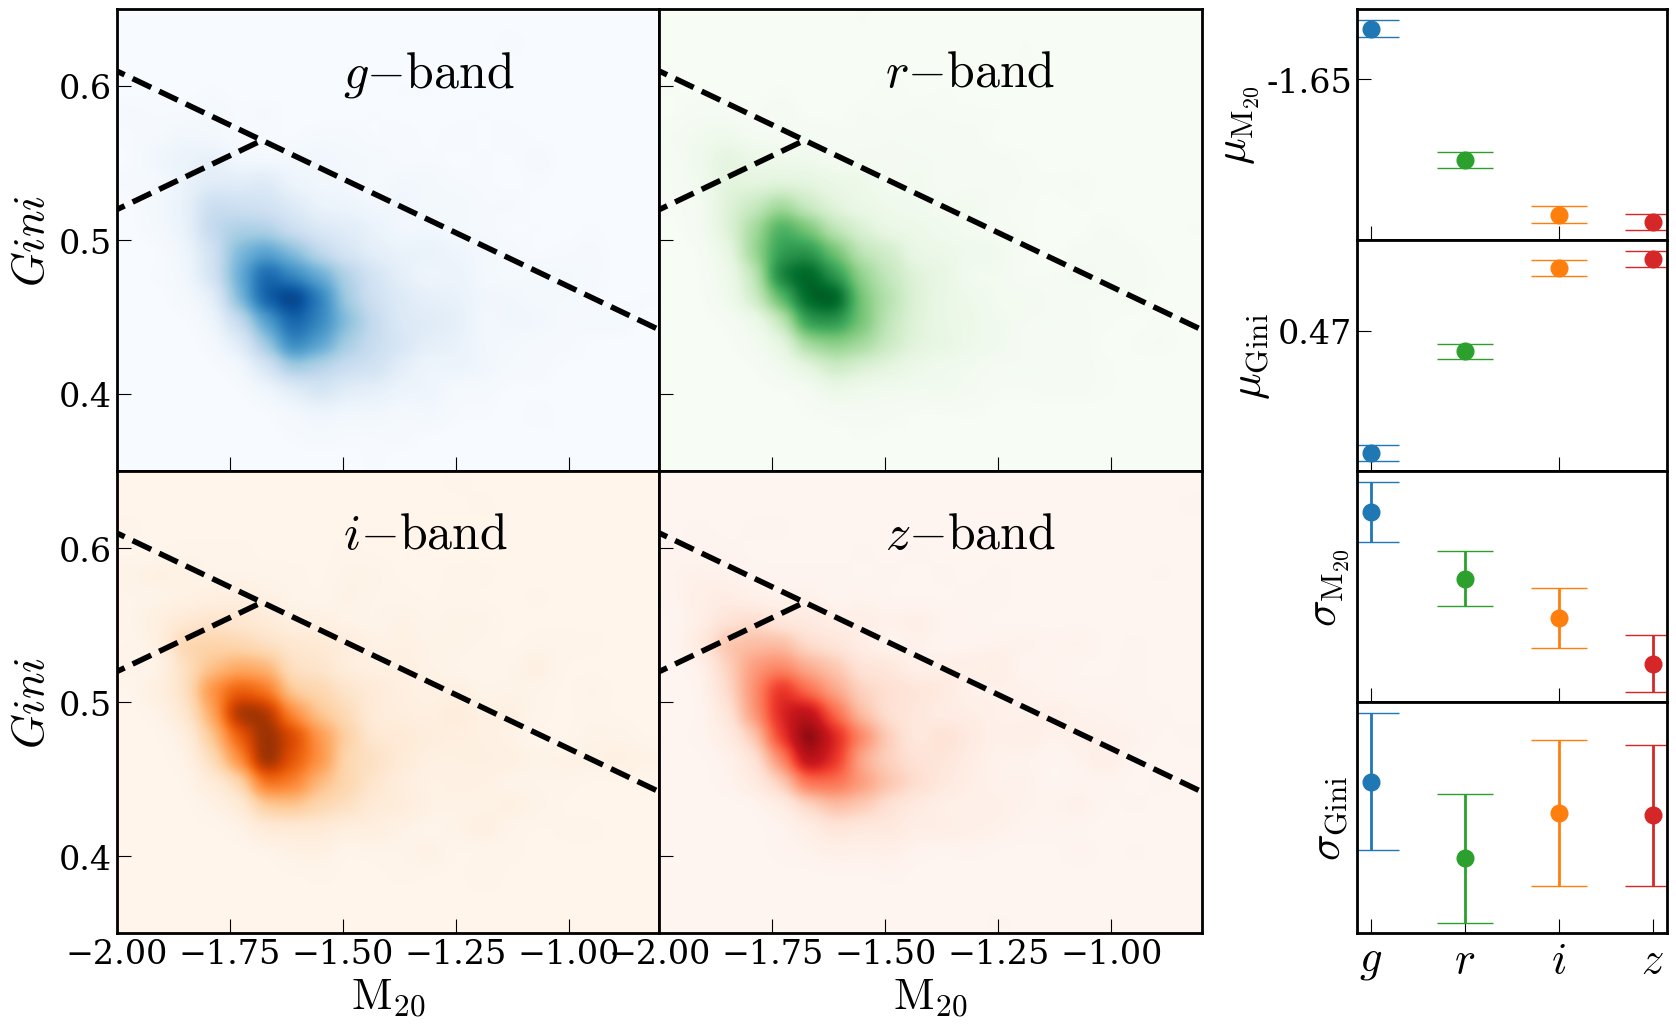

In [119]:
fig = plt.figure(figsize=(20, 12))
gs = GridSpec(4, 4, figure=fig,width_ratios=[0.35,0.35,0.1,0.2])


axl = np.array([[fig.add_subplot(gs[0:2, 0]),fig.add_subplot(gs[0:2, 1])],[fig.add_subplot(gs[2:4, 0]),fig.add_subplot(gs[2:4, 1])]]) # Top-left 2x2
axl[0,0].set_xticklabels([])
axl[0,1].set_yticklabels([])
axl[0,1].set_xticklabels([])
axl[1,1].set_yticklabels([])

axr = [fig.add_subplot(gs[0, 3]),fig.add_subplot(gs[1, 3]),fig.add_subplot(gs[2, 3]),fig.add_subplot(gs[3, 3])] # Bottom-right
axr[0].set_xticklabels([])
axr[1].set_xticklabels([])
axr[2].set_xticklabels([])


hdx = [-2.0,-0.8,0.35,0.65]
M20_arr = np.linspace(-2.2,-0.4,21)
M20_arrhalf = np.linspace(-2.2,-1.68,11)

nbins = 20
hss_arr,resi_arr = np.zeros((4,nbins,nbins)),np.zeros((4,nbins,nbins))

for i,key in enumerate(bands):

    selc = smorph[(smorph['snr_pix_'+key]>2.5)&(smorph['flag_'+key]<=1)&(smorph['r20_psf_'+key]>0.5)]
    print(selc.shape)

    axl[i//2,i%2].plot(M20_arr,merger_line(M20_arr),lw=4,ls='--',color='black')
    axl[i//2,i%2].plot(M20_arrhalf,hubble_line(M20_arrhalf),lw=4,ls='--',color='black')

    hss_arr[i],p0,p1,resi_arr[i] = hist_arr(selc['m20_'+key],selc['gini_'+key], hdx,nbins)
    
    im = axl[i//2,i%2].imshow(hss_arr[i],cmap=bands[key][0],aspect='auto',extent = hdx,origin='lower',interpolation='gaussian')
    #im = ax[i//2,i%2].scatter(selc['m20_'+key],selc['gini_'+key],c=mst,s=40,cmap=bands[key],vmin=6,vmax=10,alpha=0.8)
    #print(p0,p1)
    for j,ley in enumerate(range(4)):
        axr[j].errorbar(i,p0[ley],yerr=p1[ley],color=bands[key][1],marker='o',markersize=12,elinewidth=2,capsize=20)
    
    axl[i//2,i%2].text(-1.5,0.6,labels[i]+r'$-band$',fontsize=36)
    axl[i//2,i%2].set_ylim((0.35,0.65))
    axl[i//2,i%2].set_xlim((-2.0,-0.8))

for j in range(2):
    axl[j,0].set_ylabel( r'${\it Gini}$',fontsize=32)
    axl[1,j].set_xlabel(r'$M_{20}$',fontsize=32)
    #plt.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=0,vmax=2), cmap=bands[k]), ax=ax1[i],orientation='horizontal',label=r'$A_S$')
axr[-1].xaxis.set_major_locator(ticker.FixedLocator(positions))
axr[-1].xaxis.set_major_formatter(ticker.FixedFormatter(labels))

tick_form = [[-1.65,-1.62],[0.47,0.48],[0.12,0.125],[3.5e-2,3.6e-2]]
tick_lab = [r'$\mu_{M_{20}}$',r'$\mu_{Gini}$',r'$\sigma_{M_{20}}$',r'$\sigma_{Gini}$']
for i in range(4):
    axr[i].set_ylabel(tick_lab[i],fontsize=32)
    axr[i].yaxis.set_major_locator(ticker.FixedLocator(tick_form[i]))
    axr[i].yaxis.set_major_formatter(ticker.FixedFormatter([str(l) for l in tick_form[i]]))
axr[-1].tick_params(axis='x', labelsize=32)

plt.subplots_adjust(wspace=0.0,hspace=0.0)
#plt.savefig('GM20loci_fit.pdf',bbox_inches='tight')


(3698, 78)
(3947, 78)
(2357, 78)
(2415, 78)


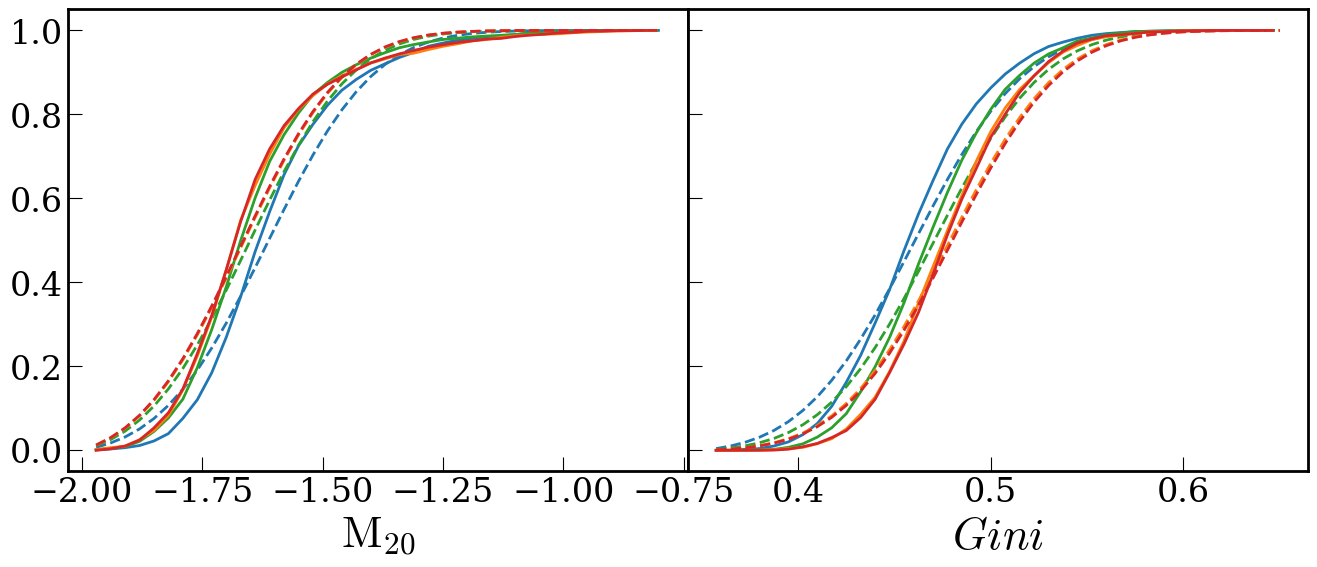

In [53]:
fig,ax=plt.subplots(1,2,figsize=(16,6),sharex='col',sharey=True)

hdx = [-2.0,-0.8,0.35,0.65]

dz=1.0/40.0
xx,yy=np.arange(dz,1+dz,dz),np.arange(dz,1+2*dz,dz)
m20_arr,gini_arr = xx*(hdx[1]-hdx[0]) + hdx[0],yy[:-1]*(hdx[3]-hdx[2]) + hdx[2]

for i,key in enumerate(bands):
    selc = smorph[(smorph['snr_pix_'+key]>2.5)&(smorph['flag_'+key]<=1)&(smorph['r20_psf_'+key]>0.5)]
    print(selc.shape)
    #ax[0].plot(m20_arr,np.sum(hss_arr[i],axis=0),lw=2,color=bands[key][1])
    #ax[0].plot(m20_arr,np.sum(hss_arr[i]-resi_arr[i],axis=0),ls='none',marker='o',markersize=8,color=bands[key][1])
    ax[0].plot(m20_arr,np.cumsum(np.sum(hss_arr[i]-resi_arr[i],axis=0))/np.sum(hss_arr[i]-resi_arr[i]),ls='--',lw=2,color=bands[key][1])

    bin_sat, bin_edg = np.histogram(selc['m20_'+key],bins=m20_arr)
    ax[0].plot(bin_edg[:-1],np.cumsum(bin_sat)/np.sum(bin_sat),lw=2,color=bands[key][1])


    #ax[1].plot(gini_arr,np.sum(hss_arr[i],axis=1),lw=2,color=bands[key][1])
    #ax[1].plot(gini_arr,np.sum(hss_arr[i]-resi_arr[i],axis=1),ls='none',marker='o',markersize=8,color=bands[key][1])
    ax[1].plot(gini_arr,np.cumsum(np.sum(hss_arr[i]-resi_arr[i],axis=1))/np.sum(hss_arr[i]-resi_arr[i]),ls='--',lw=2,color=bands[key][1])

    bin_sat, bin_edg = np.histogram(selc['gini_'+key],bins=gini_arr)
    ax[1].plot(bin_edg[:-1],np.cumsum(bin_sat)/np.sum(bin_sat),lw=2,color=bands[key][1])
    
    #axl[i//2,i%2].set_ylim((0.35,0.65))
    #axl[i,0].set_xlim((-2.0,-0.8))

ax[1].set_xlabel( r'${\it Gini}$',fontsize=32)
ax[0].set_xlabel(r'$M_{20}$',fontsize=32)
plt.subplots_adjust(wspace=0.0,hspace=0.0)


In [11]:
zsp_bins = np.logspace(-1.4,-1,5)
print(zsp_bins)
zsp_bw = 0.5*(zsp_bins[1]-zsp_bins[0])

mst_bins = np.linspace(8.0,10.0,5)
print(mst_bins)
mst_bw = 0.5*(mst_bins[1]-mst_bins[0])

mst_bins1 = np.linspace(8,9,5)
mst_bw1 = 0.5*(mst_bins1[1]-mst_bins1[0])

ls_bins = [(0, (1, 10)),(0, (1, 5)),(0, (1, 1)),'-']

[0.03981072 0.05011872 0.06309573 0.07943282 0.1       ]
[ 8.   8.5  9.   9.5 10. ]


(3698, 78)
(209, 78)
(1066, 78)
(1209, 78)
(276, 78)
(3947, 78)
(238, 78)
(1154, 78)
(1285, 78)
(287, 78)


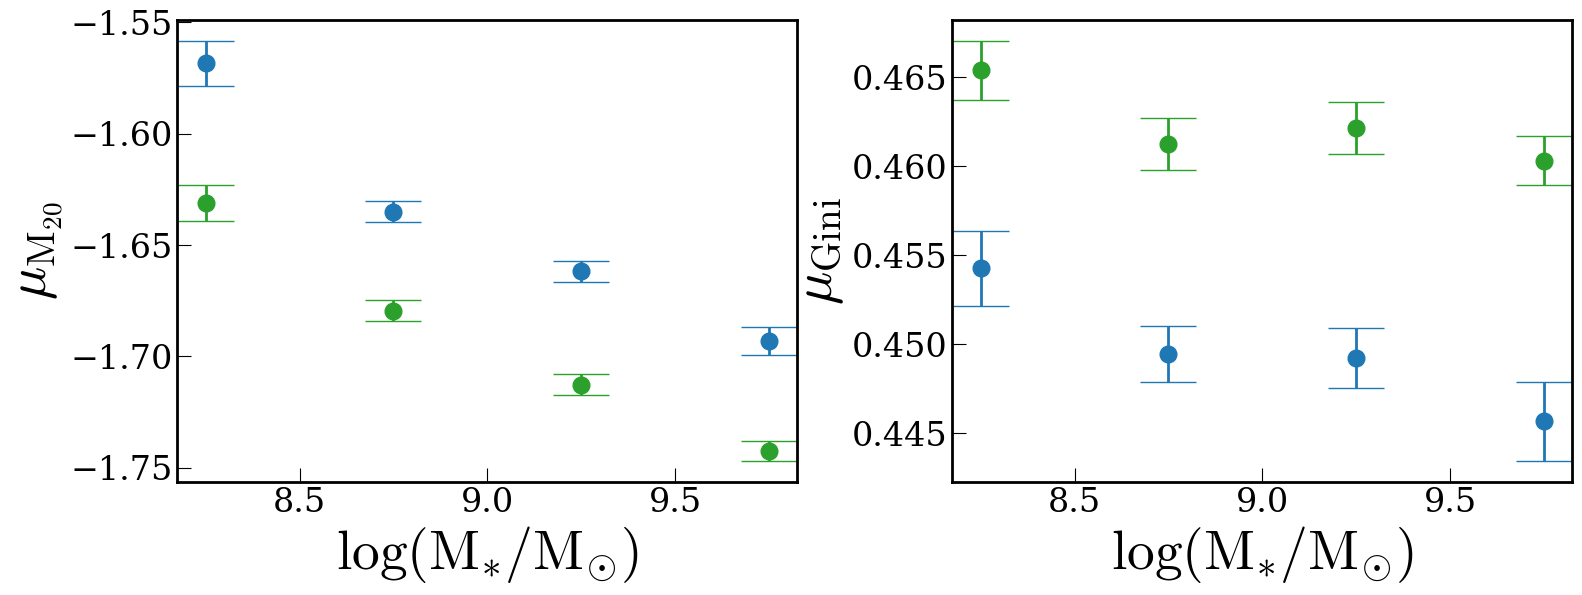

In [127]:
fig,ax=plt.subplots(1,2,figsize=(18,6),sharex='row')

hdx = [-2.0,-1.0,0.4,0.6]

for i,key in enumerate(bands):
    if i>1: continue
    selc = smorph[(smorph['snr_pix_'+key]>2.5)&(smorph['flag_'+key]<=1)&(smorph['r20_psf_'+key]>0.5)]
    zspec = sources['zspec'].iloc[selc['ind1']]
    mst = sources['logM'].iloc[selc['ind1']]
    print(selc.shape)

    p_arr = np.zeros((4,4))
    for j in range(4):
        s_inbin = selc.iloc[np.where((mst>=mst_bins[j])&(mst<mst_bins[j+1])&(zspec>=0.05)&(zspec<0.1))[0]]
        print(s_inbin.shape)

        hss_arr,p0,p1,resi = hist_arr(s_inbin['m20_'+key],s_inbin['gini_'+key], hdx,nbins)
        #im = axl[j//2,j%2].imshow(hss_arr,cmap=bands[key][0],aspect='auto',extent = hdx,origin='lower',interpolation='gaussian')
        #p_arr[j,:] = p0[1:5]
        for n in range(2):
            ax[n].errorbar(mst_bins[j]+mst_bw,p0[n],yerr=p1[n],color=bands[key][1],marker='o',markersize=12,elinewidth=2,capsize=20)

#ax[0].text(0.045,-1.61,r'$0.05<{\it z}_{spec}<0.1$'+'\n '+r'$\langle SNR \rangle>2.5$',fontsize=32)
ax[0].set_ylabel( r'$\mu_{M_{20}}$',fontsize=40)
ax[1].set_ylabel( r'$\mu_{Gini}$',fontsize=40)
ax[0].set_xlabel( r'$log(M_{\ast}/M_{\odot})$',fontsize=40)
ax[1].set_xlabel( r'$log(M_{\ast}/M_{\odot})$',fontsize=40)
ax[1].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.3f}"))


plt.subplots_adjust(wspace=0.25)
#plt.savefig('GM20loci_M.pdf',bbox_inches='tight')


(3698, 78)
(317, 78)
(372, 78)
(527, 78)
(374, 78)
(3947, 78)
(339, 78)
(407, 78)
(590, 78)
(393, 78)


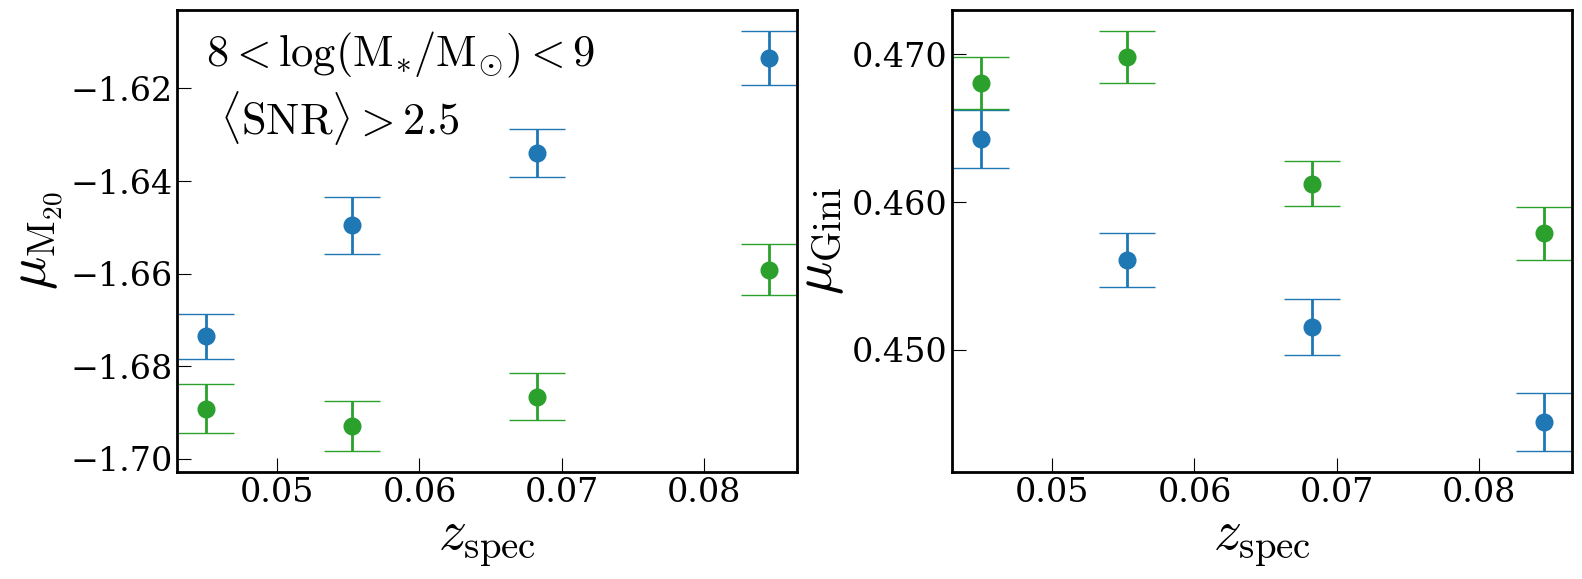

In [129]:
fig,ax=plt.subplots(1,2,figsize=(18,6))

hdx = [-2.0,-1.0,0.4,0.6] 

for i,key in enumerate(bands):
    if i>1: continue
    selc = smorph[(smorph['snr_pix_'+key]>2.5)&(smorph['flag_'+key]<=1)&(smorph['r20_psf_'+key]>0.5)]
    zspec = sources['zspec'].iloc[selc['ind1']]
    mst = sources['logM'].iloc[selc['ind1']]
    print(selc.shape)

    #p_arr = np.zeros((4,4))
    for j in range(4):
        s_inbin = selc.iloc[np.where((zspec>=zsp_bins[j])&(zspec<zsp_bins[j+1])&(mst>=8)&(mst<9))[0]]
        print(s_inbin.shape)

       
        hss_arr,p0,p1,resi = hist_arr(s_inbin['m20_'+key],s_inbin['gini_'+key], hdx,nbins)
        #im = axl[j//2,j%2].imshow(hss_arr,cmap=bands[key][0],aspect='auto',extent = hdx,origin='lower',interpolation='gaussian')
        #p_arr[j,:] = p0[:4]
        for n in range(2):
            ax[n].errorbar(zsp_bins[j]+zsp_bw,p0[n],yerr=p1[n],color=bands[key][1],marker='o',markersize=12,elinewidth=2,capsize=20)

        '''
        med_m20,med_gini = np.median(s_inbin['m20_'+key]),np.median(s_inbin['gini_'+key])
        err_m20 = np.array([[med_m20-np.percentile(s_inbin['m20_'+key],q=16),np.percentile(s_inbin['m20_'+key],q=84)-med_m20]]).reshape((2, 1))
        err_gini = np.array([[med_gini-np.percentile(s_inbin['gini_'+key],q=16),np.percentile(s_inbin['gini_'+key],q=84)-med_gini]]).reshape((2, 1))
   
        ax[0].errorbar(zsp_bins[j]+zsp_bw,med_m20,yerr=0.1*err_m20,color=bands[key][1],marker='*',markersize=12,elinewidth=2,capsize=20)
        ax[1].errorbar(zsp_bins[j]+zsp_bw,med_gini,yerr=0.1*err_gini,color=bands[key][1],marker='*',markersize=12,elinewidth=2,capsize=20)
        '''

ax[0].text(0.045,-1.63,r'$8<log(M_{\ast}/M_{\odot})<9$'+'\n '+r'$\langle SNR \rangle>2.5$',fontsize=32)
ax[0].set_ylabel( r'$\mu_{M_{20}}$',fontsize=40)
ax[1].set_ylabel( r'$\mu_{Gini}$',fontsize=40)

for k in range(2):
    ax[k].set_xlabel( r'${\it z}_{spec}$',fontsize=40)
ax[1].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.3f}"))


plt.subplots_adjust(wspace=0.25,hspace=0.2)
#plt.savefig('GM20loci_redshift.pdf',bbox_inches='tight')


In [13]:
def gini_correction(G,Reff,SNR): return G*(0.83-0.59/Reff)+0.1*np.tanh(SNR)
def m20_correction(M20,Reff): return (0.74-1/Reff)*M20-0.5

(3698, 78)
(317, 78)
(372, 78)
(527, 78)
(374, 78)
(3947, 78)
(339, 78)
(407, 78)
(590, 78)
(393, 78)


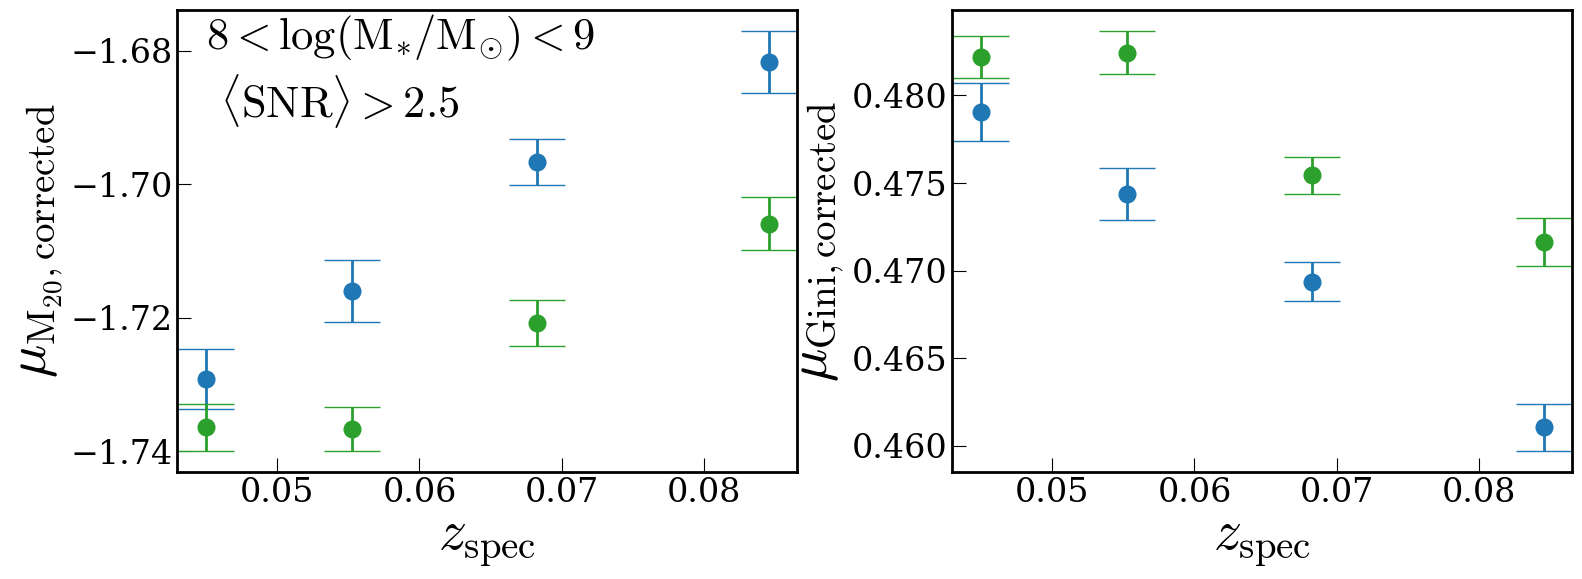

In [124]:
fig,ax=plt.subplots(1,2,figsize=(18,6))

hdx = [-2.0,-1.0,0.4,0.6]     

for i,key in enumerate(bands):
    if i>1: continue
    selc = smorph[(smorph['snr_pix_'+key]>2.5)&(smorph['flag_'+key]<=1)&(smorph['r20_psf_'+key]>0.5)]
    zspec = sources['zspec'].iloc[selc['ind1']]
    mst = sources['logM'].iloc[selc['ind1']]
    print(selc.shape)

    #p_arr = np.zeros((4,4))
    for j in range(4):
        s_inbin = selc.iloc[np.where((zspec>=zsp_bins[j])&(zspec<zsp_bins[j+1])&(mst>=8)&(mst<9))[0]]
        print(s_inbin.shape)

        delG = gini_correction(s_inbin['gini_'+key],s_inbin['rpetro_'+key]/0.262,s_inbin['snr_pix_'+key]) 
        delM20 = m20_correction(s_inbin['m20_'+key],s_inbin['rpetro_'+key]/0.262) 


        hss_arr,p0,p1,resi = hist_arr(delM20,delG, hdx,nbins)
        for n in range(2):
            ax[n].errorbar(zsp_bins[j]+zsp_bw,p0[n],yerr=p1[n],color=bands[key][1],marker='o',markersize=12,elinewidth=2,capsize=20)


ax[0].text(0.045,-1.69,r'$8<log(M_{\ast}/M_{\odot})<9$'+'\n '+r'$\langle SNR \rangle>2.5$',fontsize=32)
ax[0].set_ylabel( r'$\mu_{M_{20},corrected}$',fontsize=40)
ax[1].set_ylabel( r'$\mu_{Gini,corrected}$',fontsize=40)

for k in range(2):
    ax[k].set_xlabel( r'${\it z}_{spec}$',fontsize=40)
ax[1].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.3f}"))


plt.subplots_adjust(wspace=0.25,hspace=0.2)
#plt.savefig('GM20loci_systematics.pdf',bbox_inches='tight')


(5664, 78)
(459, 78)
(604, 78)
(944, 78)
(767, 78)
(5469, 78)
(455, 78)
(579, 78)
(902, 78)
(724, 78)


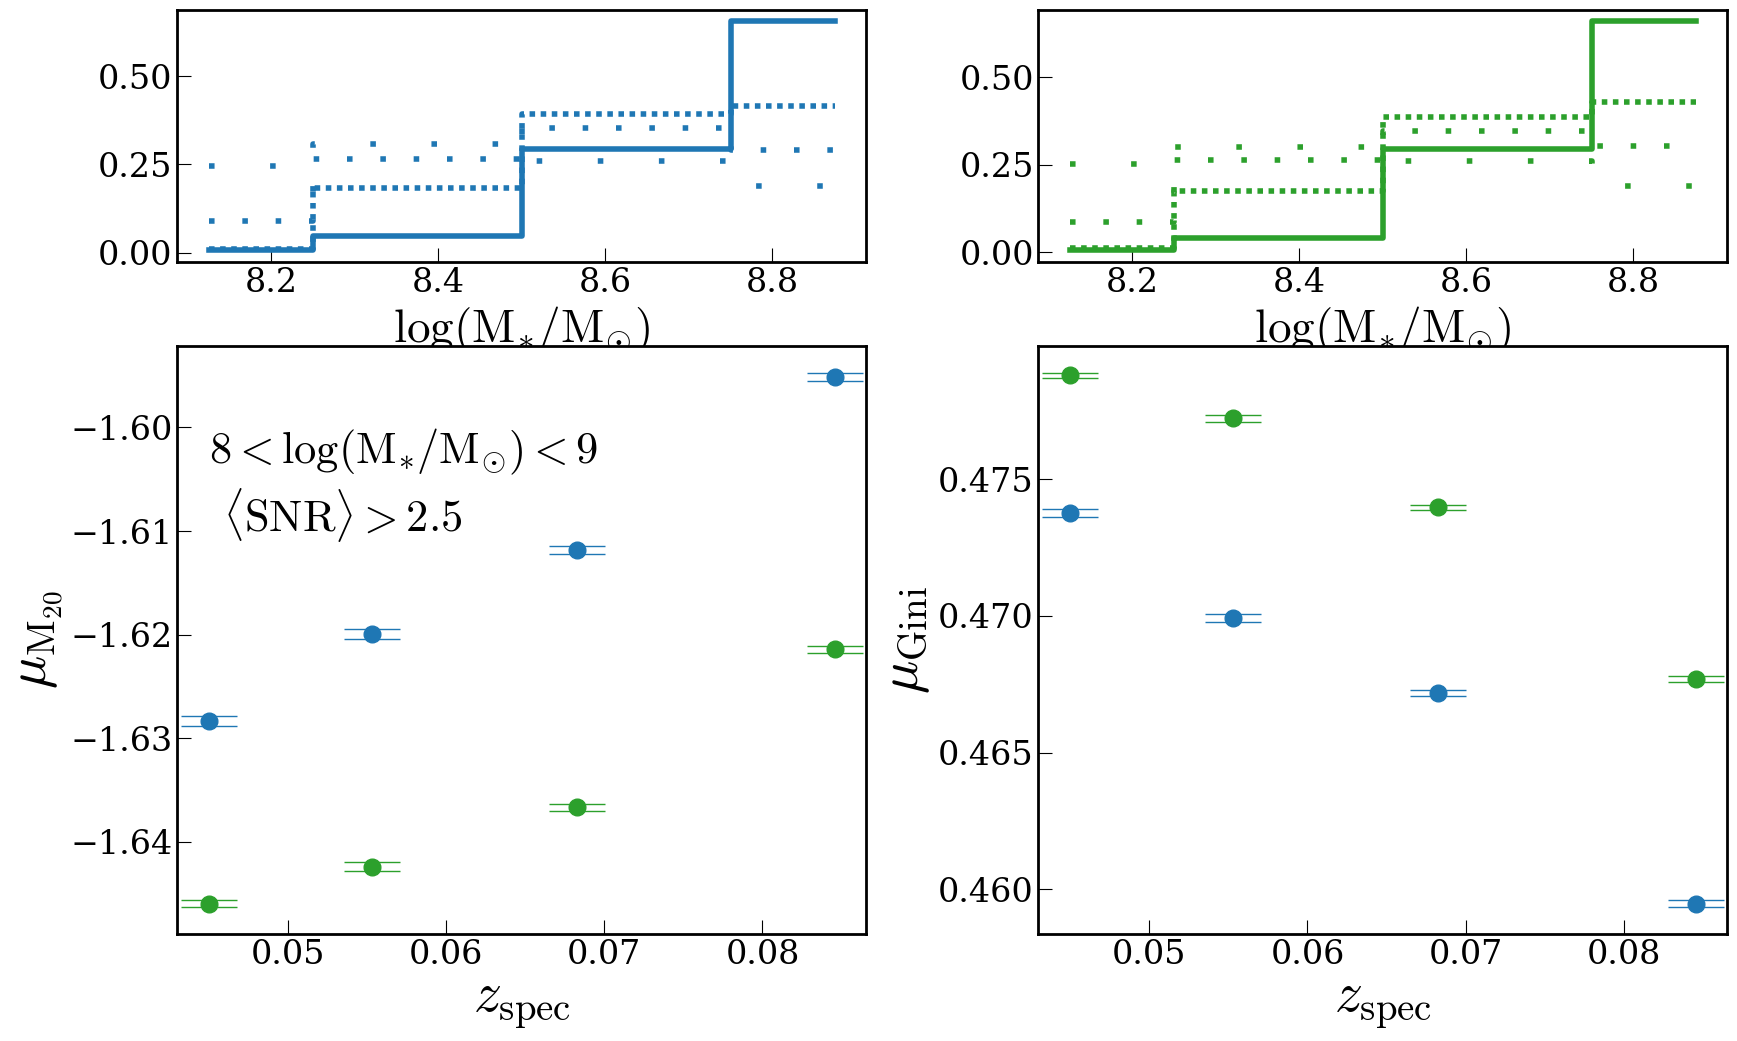

In [35]:
fig,ax=plt.subplots(2,2,figsize=(20,12),height_ratios=[0.3,0.7])

hdx = [-2.0,-1.0,0.4,0.6]     

for i,key in enumerate(bands):
    if i>1: continue
    selc = smorph[(smorph['snr_pix_'+key]>2.5)&(smorph['flag_'+key]<=1)]
    zspec = sources['zspec'].iloc[selc['ind1']]
    mst = sources['logM'].iloc[selc['ind1']]
    print(selc.shape)

    #p_arr = np.zeros((4,4))
    for j in range(4):
        s_inbin = selc.iloc[np.where((zspec>=zsp_bins[j])&(zspec<zsp_bins[j+1])&(mst>=8)&(mst<9))[0]]
        print(s_inbin.shape)

        zmst_inbin = sources['logM'].iloc[s_inbin['ind1']]

        bin_sat, bin_edg = np.histogram(zmst_inbin,bins=mst_bins1)
        ax[0,i].step(mst_bins1[:-1]+mst_bw1,bin_sat/len(zmst_inbin),c=bands[key][1],lw=4,where='mid',ls=ls_bins[j]) 
   
        hss_arr,p0,p1,resi = hess_arr(s_inbin['m20_'+key],s_inbin['gini_'+key], hdx,40)
        #im = axl[j//2,j%2].imshow(hss_arr,cmap=bands[key][0],aspect='auto',extent = hdx,origin='lower',interpolation='gaussian')
        #p_arr[j,:] = p0[:4]
        for n in range(2):
            ax[1,n].errorbar(zsp_bins[j]+zsp_bw,p0[n],yerr=p1[n],color=bands[key][1],marker='o',markersize=12,elinewidth=2,capsize=20)

ax[1,0].text(0.045,-1.61,r'$8<log(M_{\ast}/M_{\odot})<9$'+'\n '+r'$\langle SNR \rangle>2.5$',fontsize=32)
ax[1,0].set_ylabel( r'$\mu_{M_{20}}$',fontsize=40)
ax[1,1].set_ylabel( r'$\mu_{Gini}$',fontsize=40)

for k in range(2):
    ax[1,k].set_xlabel( r'${\it z}_{spec}$',fontsize=40)
    ax[0,k].set_xlabel( r'$log(M_{\ast}/M_{\odot})$',fontsize=34)
ax[1,1].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.3f}"))


plt.subplots_adjust(wspace=0.25,hspace=0.2)
plt.savefig('GM20loci_redshift.pdf',bbox_inches='tight')


(3698, 78)
[[Model]]
    Model(gaussian_2d)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 71
    # data points      = 1600
    # variables        = 6
    chi-square         = 8.0622e-05
    reduced chi-square = 5.0578e-08
    Akaike info crit   = -26873.5942
    Bayesian info crit = -26841.3276
    R-squared          = 0.93415329
[[Variables]]
    mu_x:     0.31320530 +/- 0.00188611 (0.60%) (init = 0.5125)
    mu_y:     0.21136423 +/- 0.00474043 (2.24%) (init = 0.5125)
    sigma_x:  0.16586139 +/- 0.00165202 (1.00%) (init = 0.2885849)
    sigma_y:  0.31521637 +/- 0.00445616 (1.41%) (init = 0.2885849)
    rho:      0.61780700 +/- 0.00911752 (1.48%) (init = -0.8)
    norm:     8.3806e-04 +/- 1.1521e-05 (1.37%) (init = 0.004025055)
[[Correlations]] (unreported correlations are < 0.100)
    C(sigma_y, norm)    = +0.8607
    C(mu_x, mu_y)       = +0.8198
    C(mu_y, norm)       = -0.7619
    C(mu_y, sigma_y)    = -0.7583
    C(sigma_x, rho)     = +0.6762
    C

/var/folders/_b/znph9d951ln009y69l1s4tn00000gn/T/ipykernel_69110/1143492913.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  axr[i].yaxis.set_major_formatter(ticker.FixedFormatter([str(l) for l in tick_form[i]]))


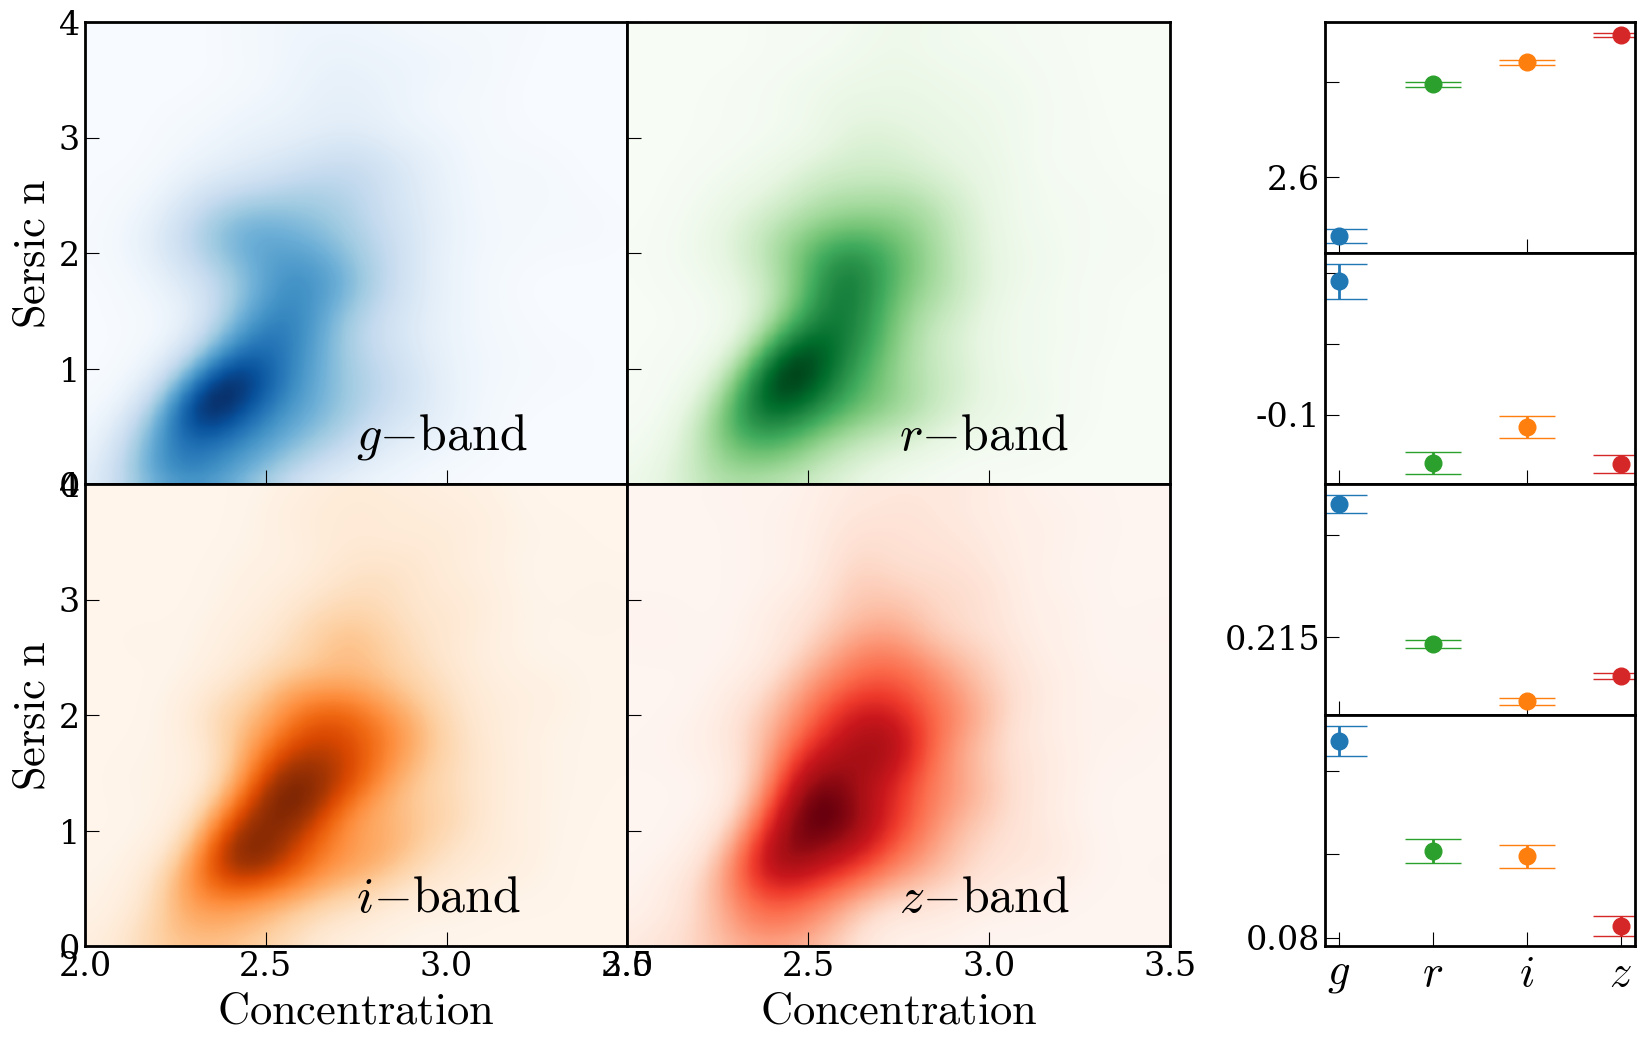

In [13]:
fig = plt.figure(figsize=(20, 12))
gs = GridSpec(4, 4, figure=fig,width_ratios=[0.35,0.35,0.1,0.2])


axl = np.array([[fig.add_subplot(gs[0:2, 0]),fig.add_subplot(gs[0:2, 1])],[fig.add_subplot(gs[2:4, 0]),fig.add_subplot(gs[2:4, 1])]]) # Top-left 2x2
axl[0,0].set_xticklabels([])
axl[0,1].set_yticklabels([])
axl[0,1].set_xticklabels([])
axl[1,1].set_yticklabels([])

axr = [fig.add_subplot(gs[0, 3]),fig.add_subplot(gs[1, 3]),fig.add_subplot(gs[2, 3]),fig.add_subplot(gs[3, 3])] # Bottom-right
axr[0].set_xticklabels([])
axr[1].set_xticklabels([])
axr[2].set_xticklabels([])


hdx = [2.0,3.5,0.0,4.0]

for i,key in enumerate(bands):

    selc = smorph[(smorph['snr_pix_'+key]>2.5)&(smorph['flag_'+key]<=1)&(smorph['r20_psf_'+key]>0.5)]
    print(selc.shape)

    hss_arr,p0,p1,resi = hess_arr(selc['c_'+key],selc['n_'+key], hdx,40)
    im = axl[i//2,i%2].imshow(hss_arr,cmap=bands[key][0],aspect='auto',extent = hdx,origin='lower',interpolation='gaussian')
    #im = ax[i//2,i%2].scatter(selc['m20_'+key],selc['gini_'+key],c=mst,s=40,cmap=bands[key],vmin=6,vmax=10,alpha=0.8)
    print(p0,p1)
    for j,ley in enumerate(range(1,5)):
        axr[j].errorbar(i,p0[ley],yerr=p1[ley],color=bands[key][1],marker='o',markersize=12,elinewidth=2,capsize=20)


    axl[i//2,i%2].text(2.75,0.3,labels[i]+r'$-band$',fontsize=36)
    axl[i//2,i%2].set_ylim((0.0,4.0))
    axl[i//2,i%2].set_xlim((2.0,3.5))

for j in range(2):
    axl[j,0].set_ylabel( r'$Sersic\ n$',fontsize=32)
    axl[1,j].set_xlabel(r'$Concentration$',fontsize=32)
    #plt.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=0,vmax=2), cmap=bands[k]), ax=ax1[i],orientation='horizontal',label=r'$A_S$')
axr[-1].xaxis.set_major_locator(ticker.FixedLocator(positions))
axr[-1].xaxis.set_major_formatter(ticker.FixedFormatter(labels))

#tick_form = [[2.55,2.60],[-0.15,-0.10],[0.205,0.215],[0.075,0.08]]
tick_lab = [r'$\mu_{C}$',r'$\mu_{n}$',r'$\sigma_{C}$',r'$\sigma_{n}$']
for i in range(4):
    #axr[i].set_ylabel(tick_lab[i],fontsize=32)
    #axr[i].yaxis.set_major_locator(ticker.FixedLocator(tick_form[i]))
    axr[i].yaxis.set_major_formatter(ticker.FixedFormatter([str(l) for l in tick_form[i]]))
axr[-1].tick_params(axis='x', labelsize=32)

plt.subplots_adjust(wspace=0.0,hspace=0.0)
plt.savefig('ACloci_fit.pdf',bbox_inches='tight')


(3698, 78)
[[Model]]
    Model(gaussian_2d)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 71
    # data points      = 1600
    # variables        = 6
    chi-square         = 3.5586e-05
    reduced chi-square = 2.2325e-08
    Akaike info crit   = -28182.1138
    Bayesian info crit = -28149.8473
    R-squared          = 0.98607894
[[Variables]]
    mu_x:     0.34601342 +/- 5.8711e-04 (0.17%) (init = 0.5125)
    mu_y:     0.38681328 +/- 5.2152e-04 (0.13%) (init = 0.5125)
    sigma_x:  0.15484897 +/- 6.0218e-04 (0.39%) (init = 0.2885849)
    sigma_y:  0.13797131 +/- 5.2634e-04 (0.38%) (init = 0.2885849)
    rho:      0.68987245 +/- 0.00282329 (0.41%) (init = -0.8)
    norm:     6.1852e-04 +/- 2.3577e-06 (0.38%) (init = 0.006505633)
[[Correlations]] (unreported correlations are < 0.100)
    C(mu_x, mu_y)       = +0.6922
    C(sigma_x, norm)    = +0.5165
    C(sigma_y, norm)    = +0.5085
    C(sigma_y, rho)     = +0.4986
    C(sigma_x, rho)     = +0.4984
    C

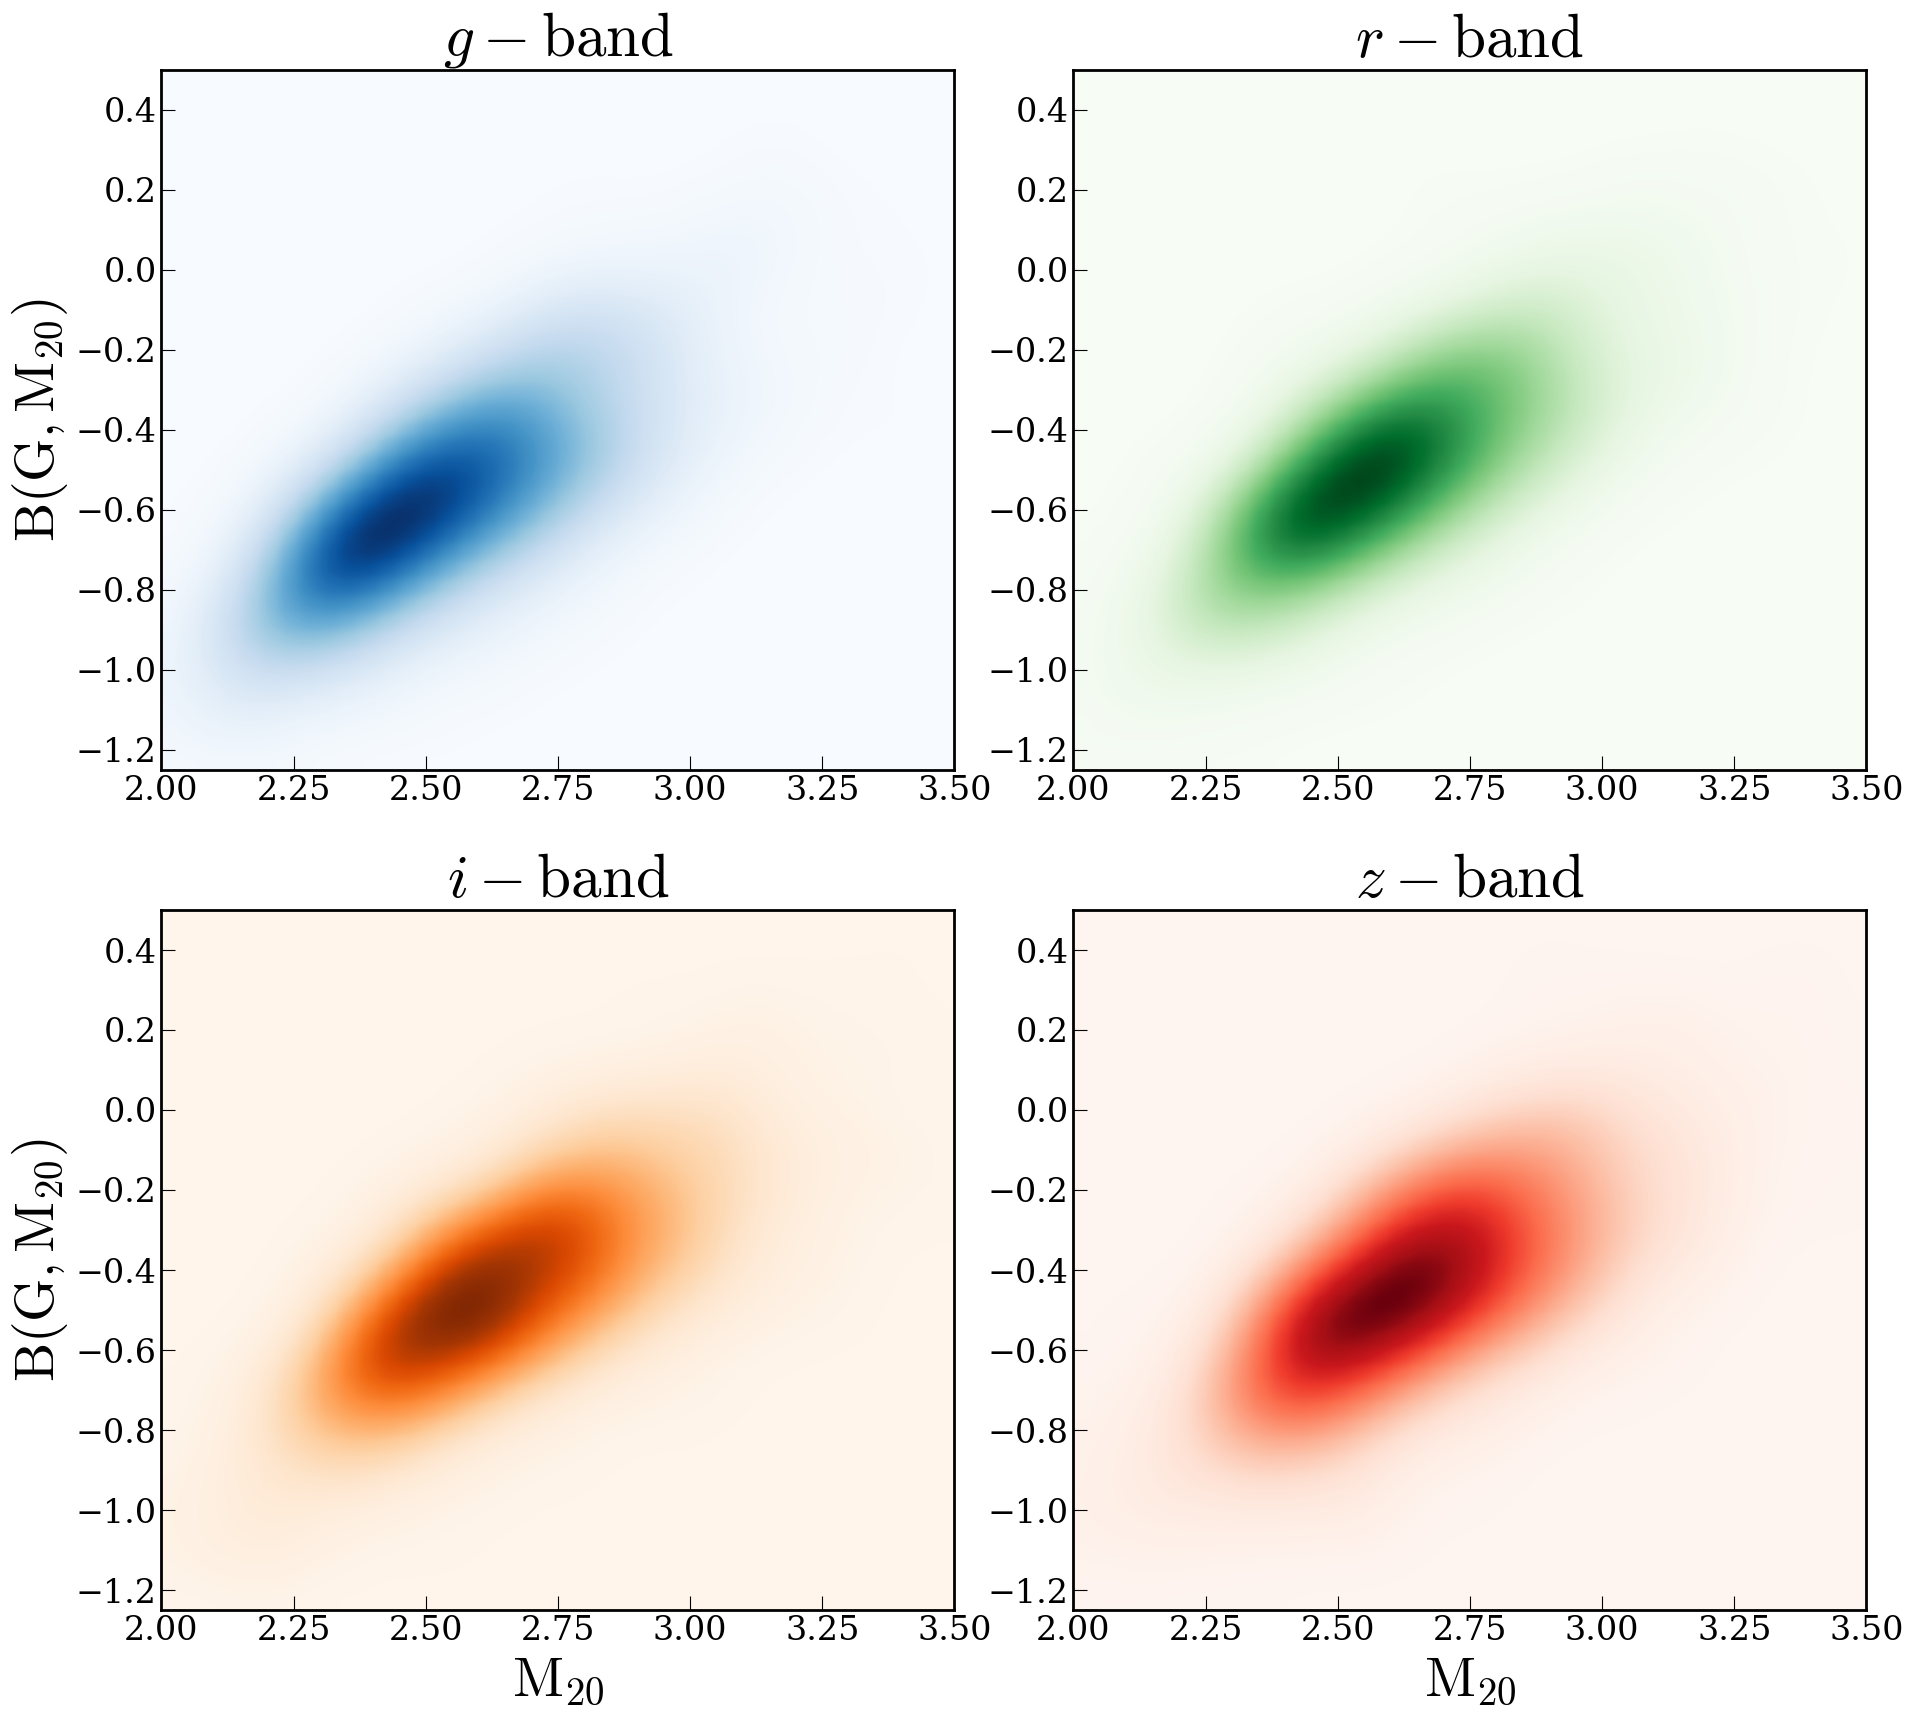

In [7]:
fig,ax=plt.subplots(2,2,figsize=(22,20))

hdx = [2.0,3.5,-1.25,0.5]

for i,key in enumerate(bands):
    selc = smorph[(smorph['snr_pix_'+key]>2.5)&(smorph['flag_'+key]<=1)&(smorph['r20_psf_'+key]>0.5)]
    print(selc.shape)

    mst = sources['logM'].iloc[selc['ind1']]
    hss_arr,p0,p1,resi = hess_arr(selc['c_'+key],BGM(selc['gini_'+key],selc['m20_'+key]), hdx,40)
    #im = ax[i//2,i%2].scatter(selc['m20_'+key],BGM(selc['gini_'+key],selc['m20_'+key]),c=mst,s=40,cmap=bands[key][0],vmin=7,vmax=10,alpha=0.8)
    im = ax[i//2,i%2].imshow(hss_arr,cmap=bands[key][0],aspect='auto',extent = hdx,origin='lower',interpolation='gaussian')

    ax[i//2,i%2].set_title(r'${\it '+key+'}-band$',fontsize=44)
    #ax[i//2,i%2].set_ylim((-0.2,0.4))
    #ax[i//2,i%2].set_xlim((-2.0,-0.8))

for j in range(2):
    ax[j,0].set_ylabel( r'$B(G,M_{20})$',fontsize=40)
    ax[1,j].set_xlabel(r'$M_{20}$',fontsize=40)



    #plt.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=0,vmax=2), cmap=bands[k]), ax=ax1[i],orientation='horizontal',label=r'$A_S$')

plt.subplots_adjust(wspace=0.15)
#plt.savefig('NPdistributions1.pdf',bbox_inches='tight')

In [ ]:
#merger_cand = np.where((morph_all[:,0,1]>merger_line(morph_all[:,0,2]))&(morph_all[:,0,2]>-1.5))[0]
merger_cand = high_snr[np.where((morph_all[high_snr,0,8]<0.3))[0]]

fig1,ax1=plt.subplots(1,4,figsize=(32,10),sharey=True)

M20_arr = np.linspace(-2,-0.5,11)
M20_arrhalf = np.linspace(-2,-1.68,11)


for i in range(4):
    mst = sources['logM'].iloc[morph_all[merger_cand,i,0]]
    #dst = np.power(10,sources['logD'].iloc[morph_all[high_snr,i,0]])


    #ax1[i].plot(M20_arr,merger_line(M20_arr),lw=4,ls='--',color='black')
    #ax1[i].plot(M20_arrhalf,hubble_line(M20_arrhalf),lw=4,ls='--',color='black')
    ax1[i].scatter(morph_all[merger_cand,i,8],morph_all[merger_cand,i,1],c=morph_all[merger_cand,i,8],s=120,cmap=filt_cmap[i],vmin=0,vmax=2,edgecolors='black')

    ax1[i].set_ylim((0.3,1.0))
    ax1[i].set_xlim((0,2))
    ax1[i].set_xlabel(r'$M_{20}$',fontsize=40)
    ax1[i].set_rasterized(True)

    plt.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=0,vmax=2), cmap=filt_cmap[i]), ax=ax1[i],orientation='horizontal',label=r'$A_S$')


ax1[0].set_ylabel( r'${\it Gini}$',fontsize=40)



plt.subplots_adjust(wspace=0.15)
#plt.savefig('NPdistributions1.pdf',bbox_inches='tight')
'''
fig1,ax1=plt.subplots(1,4,figsize=(24,8),sharey=True)

for i in range(4):
    #merger_cand = np.where(morph_all[:,i,1]>merger_line(morph_all[:,i,2]))[0]

    ax1[i].scatter(morph_all[merger_cand,i,2],morph_all[merger_cand,i,1],alpha=0.5,color=griz_col[i],s=40)

for i in range(4):
    #ax1[i].plot(M20_arr,merger_line(M20_arr),lw=3,ls='--',color='black')
    ax1[i].plot(M20_arrhalf,hubble_line(M20_arrhalf),lw=3,ls='--',color='black')
    
    ax1[i].set_ylim((0.3,1.0))
    ax1[i].set_xlim((-2,-0.5))
    ax1[i].set_xlabel(r'$M_{20}$',fontsize=36)
    ax1[i].set_rasterized(True)

ax1[0].set_ylabel( r'${\it Gini}$',fontsize=36)

plt.subplots_adjust(wspace=0.0)
'''
for k in merger_cand:
        key = sources.iloc[k]
        pos = np.array([key['RA'],key['DEC']])
        try: im = plt.imread('post_cutouts/galseg_{:.4f}_{:.4f}.png'.format(pos[0],pos[1]))
        except: continue

        fig,ax=plt.subplots(figsize=(16,8))
        ax.imshow(im)


In [ ]:

fig,ax=plt.subplots(2,2,figsize=(22,20))

M20_arr = np.linspace(-2.2,-0.4,21)
M20_arrhalf = np.linspace(-2.2,-1.68,11)


for i,k in enumerate(bands):

    selc = np.where((morph_all[:,i,9]==0)&(morph_all[:,i,10]>=2))[0]
    print(k,len(selc))
    
    ax[i//2,i%2].scatter(morph_all[~selc,i,2],SGM(morph_all[~selc,i,1],morph_all[~selc,i,2]),c=morph_all[~selc,i,8],s=80,cmap=bands[k],vmin=0,vmax=2,alpha=0.3)
    im = ax[i//2,i%2].scatter(morph_all[selc,i,2],SGM(morph_all[selc,i,1],morph_all[selc,i,2]),c=morph_all[selc,i,8],s=40,cmap=bands[k],vmin=0,vmax=2,alpha=0.5)


    divider = make_axes_locatable(ax[i//2,i%2])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')

    ax[i//2,i%2].set_title(r'${\it '+k+'}-band$',fontsize=44)
    ax[i//2,i%2].set_ylim((-0.2,0.4))
    ax[i//2,i%2].set_xlim((-2.2,-0.3))
    ax[i//2,i%2].set_rasterized(True)

for j in range(2):
    ax[j,0].set_ylabel( r'$S(G,M_{20})$',fontsize=40)
    ax[1,j].set_xlabel(r'$M_{20}$',fontsize=40)



    #plt.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=0,vmax=2), cmap=bands[k]), ax=ax1[i],orientation='horizontal',label=r'$A_S$')

#plt.subplots_adjust(wspace=0.15)
#plt.savefig('NPdistributions1.pdf',bbox_inches='tight')

# 